## Question 1

In [ ]:
import numpy as np

def generer_approbation_profil(n, m, polarisation = 0.0, bruit = 0.05): # n = nombre de votantes, m = nombre de candidates, bruit = probabilité de modifier un vote (erreur aléatoire)
#on créer un tableau de taille m (pour les m candidates) avec des 0 et 1 mis de manière aléatoire. Le a représente un vote avec par exemple dans le cas des vote par approbation 1 qui dit que la votante approuve la candidate, 0 sinon.
    a = np.random.randint(0, 2, m)
    # C'est le vote opposé de a. Si la votante approuve la candidate dans son a, alors a_barre est le vote qui ne l'approuve pas
    a_barre = 1 - a
# On créer la liste profil qui va donc contenir tous les votes
    profil = []
#on fait une boucle sur les n votantes. L'idée est que pour chaque votante : 
    for _ in range(n):
# On tire un nombre entre 0 et 1 si on est dans le cas de non polarisation
        if np.random.rand() < (1-polarisation):
            # avec le a.copy, la votante suit le vote de préférences
            vote = a.copy()
        #sinon on est dans le cas polarisé
        else:
            #on choisit aléatoirement entre les deux groupes possible (approuve ou n'approuve pas)
            if np.random.choice([True, False]):
                # le groupe opposé vote donc l'inverse
                vote = a_barre.copy()
            else:
                #sinon, la votante reste sur le vote originale
                vote = a.copy()
        
        # ajout du bruit. On parcours chaque candidate
        for j in range(m):
        #Avec une probabilité bruit, on modifie le vote si on a une erreur
            if np.random.rand() < bruit:
                #Ainsi si on a une erreur, on inverse la valeure. Ainsi, 1 devient 0 et 0 devient 1
                vote[j] = 1 - vote[j]
        # On ajoute le vote de la votante à la liste
        profil.append(vote)
    #On créer notre matrice avec en ligne les votantes et en colonne les candidates. 
    return np.array(profil)

# Exemple :
#Très peu polarisé :
if __name__ == "__main__":
    # Ici, toutes les votantes pareil car 0 polarisation et pas de bruit donc pas d'erreur
    p = generer_approbation_profil(n=10, m=5, polarisation=0.0, bruit=0)
    print("Profil très peu polarisé")
    print(p)

#Très polarisé :
if __name__ == "__main__":
    # Ici, on a une forte polarisation donc les votantes sont séparés en 2 groupes opposé. 
    p = generer_approbation_profil(n=10, m=5, polarisation=1.0, bruit=0)
    print("Profil très polarisé")
    print(p)


Profil très peu polarisé
[[0 1 0 1 0]
 [0 1 0 1 0]
 [0 1 0 1 0]
 [0 1 0 1 0]
 [0 1 0 1 0]
 [0 1 0 1 0]
 [0 1 0 1 0]
 [0 1 0 1 0]
 [0 1 0 1 0]
 [0 1 0 1 0]]
Profil très polarisé
[[1 1 1 0 1]
 [1 1 1 0 1]
 [1 1 1 0 1]
 [1 1 1 0 1]
 [0 0 0 1 0]
 [0 0 0 1 0]
 [1 1 1 0 1]
 [0 0 0 1 0]
 [1 1 1 0 1]
 [0 0 0 1 0]]


## Question 2

In [ ]:
def generer_ordre_profil(n, m, polarisation = 0.0, bruit = 0.00): # n = nombre de votantes, m = nombre de candidates, bruit = probabilité de perturber un classement
#créer une permutation aléatoire entre 1 et m. Représente donc un classement de préférences. 
    ordre = np.random.permutation(m)
    #inverse l'ordre. C'est le classement opposé
    ordre_barre = ordre[::-1]
    #liste vide pour enregistré les classements
    profil = []
    #Pour chaque votante, on génère un classement
    for _ in range(n):
        #Dans le cas de non polarisation 
        if np.random.rand() < (1-polarisation):
            #la votante suit le classement de référence
            vote = ordre.copy()
        #Sinon, on est dans le cas polarisé
        else:
            #On choisit aléatoirement un groupe. La votante fera donc partie soit du groupe qui approuve la candidate, soit du groupe qui ne l'approuve pas dans le cas des préférences par approbation
            if np.random.choice([True, False]):
                # Son vote et elle se situe donc dans le groupe opposé.
                vote = ordre_barre.copy()
            else:
                #Sinon elle se situe dans le groupe de base. 
                vote = ordre.copy()

        if np.random.rand() < bruit:
            # On choisit 2 positions différentes aux hasards
            i, j = np.random.choice(m, 2, replace=False)
            #on échange ces deux éléments
            vote[i], vote[j] = vote[j], vote[i]
        #Ajoute le classement de la votante
        profil.append(vote)

    return np.array(profil)

# Exemple :
#Très peu polarisé :
if __name__ == "__main__":
    p = generer_ordre_profil(n=10, m=5, polarisation=0.0, bruit=0)
    print("Profil très peu polarisé")
    print(p)

#Très polarisé :
if __name__ == "__main__":
    p = generer_ordre_profil(n=10, m=5, polarisation=1.0, bruit=0)
    print("Profil très polarisé")
    print(p)


Profil très peu polarisé
[[1 2 0 3 4]
 [1 2 0 3 4]
 [1 2 0 3 4]
 [1 2 0 3 4]
 [1 2 0 3 4]
 [1 2 0 3 4]
 [1 2 0 3 4]
 [1 2 0 3 4]
 [1 2 0 3 4]
 [1 2 0 3 4]]
Profil très polarisé
[[1 4 3 0 2]
 [1 4 3 0 2]
 [1 4 3 0 2]
 [2 0 3 4 1]
 [2 0 3 4 1]
 [2 0 3 4 1]
 [2 0 3 4 1]
 [2 0 3 4 1]
 [1 4 3 0 2]
 [1 4 3 0 2]]


## Question 3

In [ ]:
from enum import Enum
import numpy as np
 #On définit deux types de votes où les votes par approbations sont définit par 1 et les ordres_totaux par 0.
class TypeDeVote(Enum):
    APPROBATION = 0
    ORDRE_TOTAUX = 1
#fonction qui nous dit combien de votantes préfèrent la candidate k à la candidate l en fonction du type de vote (definit par notre enumération)
def nbr_votantes_pref(profil, k, l, type_de_vote):
    """Étant donné un profil et deux candidates d'indice k et l, cette méthode 
    retourne de nombre de votantes qui préfèrent ck à cl, étant donné le type de vote.
    """
    #equivalent d'un switch en java
    match type_de_vote:
        #Cas où on est le vote par approbation
        case TypeDeVote.APPROBATION:
            #on compte les votantes qui approuvent k mais n'approuvent pas l. On compte combien de fois c'est vrai
            return np.sum((profil[:,k] == 1) & (profil[:,l] == 0))
        #Cas où on est dans le vote par ordre totaux
        case TypeDeVote.ORDRE_TOTAUX:
            n_kl = 0
            #Pour chaque votante
            for vote in profil:
                #on regarde la position de la candidate k et de la candidate l pour la votante 
                position_k = np.where(vote == k)[0][0]
                position_l = np.where(vote == l)[0][0]
                if position_k < position_l:
                    #on incrément si k est préféré à l
                    n_kl += 1
            # On retourne le nombre totale de votantes préférant k à l 
            return n_kl


def diff_absolue(profil, k, l, type_de_vote):
    # On calcule ici combien de votante préfèrent k à l et combien de votantes préfèrent l à k
    n_kl = nbr_votantes_pref(profil, k, l, type_de_vote)
    n_lk = nbr_votantes_pref(profil, l, k, type_de_vote)
    #On retourne la différence en valeur absolue pour avoir toujours une différence positive entre ces préférences
    return abs(n_kl - n_lk)


def ensemble_des_diff_absolue(profil, type_de_vote):
    # n = nombre de votantes(ligne), m = nombre de candidates(colonne)
    n, m = profil.shape
    d_valeurs = []
    #Pour toutes les paires de candidates
    for k in range(m):
        for l in range(k+1, m):
            #On calcule la différence entre chaque paire de candidates
            d = diff_absolue(profil, k, l, type_de_vote)
            #on ajoute la valeur dans notre liste
            d_valeurs.append(d)
            #on retourne le tableau des différences
    return np.array(d_valeurs)


def ensemble_des_diff_absolue_approbation(profil):
    return ensemble_des_diff_absolue(profil, TypeDeVote.APPROBATION)


def ensemble_des_diff_absolue_ordre_totaux(profil):
        return ensemble_des_diff_absolue(profil, TypeDeVote.ORDRE_TOTAUX)


#Exemple : 
if __name__ == "__main__":
    p = generer_approbation_profil(n=10, m=5, polarisation=1.0)
    print(ensemble_des_diff_absolue_approbation(p))

        
#Exemple : 
if __name__ == "__main__":
    p = generer_ordre_profil(n=10, m=5, polarisation=1.0)
    print(ensemble_des_diff_absolue_ordre_totaux(p))
            


[0 0 5 0 0 5 0 5 0 5]
[4 4 4 4 4 4 4 4 4 4]


## Question 8 : 

In [36]:
def distance_hamming(a, b):
    # a ^ b est le XOR bit à bit de a et b: contient des 1 aux positions où a et b diffèrent, et des 0 aux positions où a et b sont identiques.
    return int(np.sum(a ^ b))

In [37]:
def distance_spearman(a, b):
    return np.sum(abs(np.subtract(a, b)))

## Question 12

In [38]:
import random

def calcul_consensus_approbation(profil):
    
    n,m = profil.shape
    consensus = [0]*m

    for col in range(m):

        somme = sum(vote[col] for vote in profil)

        if somme > n/2: 
            consensus[col] = 1
        elif somme < n/2: 
            consensus[col] = 0  
        else:
            consensus[col] = random.randint(0,1) 

    return consensus

    
def calcul_u1_approbation(profil):
    consensus = calcul_consensus_approbation(profil)
    u1 = sum([distance_hamming(vote, consensus) for vote in profil])
    return u1

profil = generer_approbation_profil(n=6, m=10, polarisation=0.3)
consensus = calcul_consensus_approbation(profil=profil)
u1 = calcul_u1_approbation(profil=profil)
print("profil:\n", profil)
print("consensus:", consensus)
print("u1:", u1)

profil:
 [[1 1 0 1 0 1 0 1 0 0]
 [0 1 0 1 0 1 0 1 0 0]
 [1 1 0 1 0 1 0 1 0 0]
 [1 1 0 1 0 1 0 1 0 0]
 [1 1 0 1 0 1 0 1 0 0]
 [0 1 0 1 0 1 0 1 0 0]]
consensus: [1, 1, 0, 1, 0, 1, 0, 1, 0, 0]
u1: 2


In [39]:
from scipy.optimize import linear_sum_assignment

def calcul_consensus_ordre(profil):

    n, m = profil.shape

    poids = np.zeros((m,m))
    for candidat in range(m):
        for rang_possible in range(m):

            pds = 0
            for vote in profil:
                index = int(np.where(vote == candidat)[0][0])
                absolue = abs(index - rang_possible)
                pds += absolue

            poids[candidat][rang_possible] = pds

    candidate_ind, rank_ind = linear_sum_assignment(poids)

    consensus = [0]*m
    for i in range(m):
        consensus[rank_ind[i]] = int(candidate_ind[i])

    return consensus


def calcul_u1_ordre(profil):
    consensus = calcul_consensus_ordre(profil=profil)
    u1 = sum([distance_spearman(vote, consensus) for vote in profil])
    return u1

profil = generer_ordre_profil(n=6, m=10, polarisation=0.4)
consensus = calcul_consensus_ordre(profil=profil)
u1 = calcul_u1_ordre(profil=profil)
print("profil:\n", profil)
print("consensus:", consensus)
print("u1:", u1)


profil:
 [[2 0 8 3 7 4 6 5 9 1]
 [2 0 8 3 7 4 6 5 9 1]
 [1 9 5 6 4 7 3 8 0 2]
 [2 0 8 3 7 4 6 5 9 1]
 [2 0 8 3 7 4 6 5 9 1]
 [2 0 8 3 7 4 6 5 9 1]]
consensus: [2, 0, 8, 3, 7, 4, 6, 5, 9, 1]
u1: 38


## Question 13

In [40]:
import random

def calcul_u2_approbation(profil, max_iter=10_000):

    n, m = profil.shape

    a1 = np.random.randint(0, 2, size=m) 
    a2 = np.random.randint(0, 2, size=m) 

    for i in range(max_iter):

        cluster1 = []
        cluster2 = []

        for votes in profil : 
            if distance_hamming(votes, a1) < distance_hamming(votes, a2) : 
                cluster1.append(votes)
            else : 
                cluster2.append(votes)

        if len(cluster1) > 0:
            a1BIS = calcul_consensus_approbation(np.array(cluster1))
        else:
            a1BIS = np.random.randint(0, 2, size=m)

        if len(cluster2) > 0:
            a2BIS = calcul_consensus_approbation(np.array(cluster2))
        else:
            a2BIS = np.random.randint(0, 2, size=m)

        if np.array_equal(a1, a1BIS) and np.array_equal(a2, a2BIS):
            a1 = a1BIS 
            a2 = a2BIS
            u2 = sum([distance_hamming(vote, a1) for vote in cluster1]) + sum([distance_hamming(vote, a2) for vote in cluster2])
            return int(u2)            
        else : 
            a1 = a1BIS 
            a2 = a2BIS

    raise ValueError()



profil = generer_approbation_profil(n=6, m=10, polarisation=0.0)
print("Profil:\n", profil)
u1 = calcul_u1_approbation(profil)
u2 = calcul_u2_approbation(profil)
print("u1:", u1)
print("u2:", u2)
print("u1-u2:", u1-u2)

Profil:
 [[0 0 0 1 1 0 0 0 0 0]
 [0 0 0 1 0 1 0 1 0 0]
 [0 0 0 1 0 1 1 1 0 0]
 [0 0 0 1 0 1 0 1 0 0]
 [0 0 0 1 0 1 0 1 0 0]
 [0 0 0 1 0 1 0 1 0 0]]
u1: 4
u2: 1
u1-u2: 3


In [41]:
import random

def calcul_u2_ordre(profil, max_iter=10_000):
    n, m = profil.shape

    a1 = np.arange(m)
    np.random.shuffle(a1)

    a2 = np.arange(m)
    np.random.shuffle(a2)

    for i in range(max_iter):

        cluster1 = []
        cluster2 = []

        for votes in profil : 
            if distance_spearman(votes, a1) < distance_spearman(votes, a2) : 
                cluster1.append(votes)
            else : 
                cluster2.append(votes)

        if len(cluster1) > 0:
            a1BIS = calcul_consensus_ordre(np.array(cluster1))
        else:
            a1BIS = a1
            np.random.shuffle(a1BIS)

        if len(cluster2) > 0:
            a2BIS = calcul_consensus_ordre(np.array(cluster2))
        else:
            a2BIS = a2
            np.random.shuffle(a2BIS)

        if np.array_equal(a1, a1BIS) and np.array_equal(a2, a2BIS):
            a1 = a1BIS 
            a2 = a2BIS
            u2 = sum([distance_spearman(vote, a1) for vote in cluster1]) + sum([distance_spearman(vote, a2) for vote in cluster2])
            return int(u2)            
        else : 
            a1 = a1BIS 
            a2 = a2BIS

    raise ValueError()

profil = generer_ordre_profil(n=6, m=10, polarisation=1.0)
print("Profil:\n", profil)
u1 = calcul_u1_ordre(profil)
u2 = calcul_u2_ordre(profil)
print("u1:", u1)
print("u2:", u2)
print("u1-u2:", u1-u2)

Profil:
 [[0 7 4 8 1 6 9 5 2 3]
 [3 2 5 9 6 1 8 4 7 0]
 [0 7 4 8 1 6 9 5 2 3]
 [3 2 5 9 6 1 8 4 7 0]
 [3 2 5 9 6 1 8 4 7 0]
 [0 7 4 8 1 6 9 5 2 3]]
u1: 90
u2: 0
u1-u2: 90


## Question 14 : 

In [ ]:
def phi_hamming(profil):
    # n = nombre de votantes (ligne), m = nombre de candidate (colonne)
    n, m = profil.shape
    # Si n = 0 ou m = 0 alors on a une erreur car on ne peut pas diviser par 0 dans la formule d'où le ValueError
    if n == 0 or m == 0:
        raise ValueError()
    #On calcule u1 et u2 dans le cas des approbations car distance Hamming s'applique dans ce cas là
    u1_h = calcul_u1_approbation(profil=profil)
    u2_h = calcul_u2_approbation(profil=profil)
    #la formule donné dans l'énoncé
    phi = 2 * (u1_h-u2_h) / (n*m)

    return phi

In [ ]:
def phi_spearman(p):
    # n = nombre de votantes (ligne), m = nombre de candidate (colonne)
    n, m = p.shape
    # Si n = 0 ou m = 0 alors on a une erreur car on ne peut pas diviser par 0 dans la formule d'où le ValueError
    if n == 0 or m == 0:
        raise ValueError()
    #On calcule u1 et u2 dans le cas des ordres totaux car distance Spearman s'applique dans ce cas là
    u1_h = calcul_u1_ordre(profil=p)
    u2_h = calcul_u2_ordre(profil=p)
    #la formule donné dans l'énoncé
    phi = 4 * (u1_h-u2_h) / (n*m*m)

    return phi

### Test

Ici, on a une polarisation de 0.9 soit proche de 1. On devrait donc obtenir un 𝛟 proche de 1.

In [44]:
p = generer_approbation_profil(20, 6, 0.9)
print(phi_hamming(p))

0.6333333333333333


Ici, on a une polarisation très faible (de 0.1). On devrait donc obtenir un 𝛟 proche de 0.

In [45]:
p = generer_approbation_profil(20, 6, 0.1)
print(phi_hamming(p))

0.1


In [46]:
p = generer_ordre_profil(20, 6, 1.0)
print(phi_spearman(p))

0.8


## Question 15 : 

### Évolution des mesures 𝜑_dh

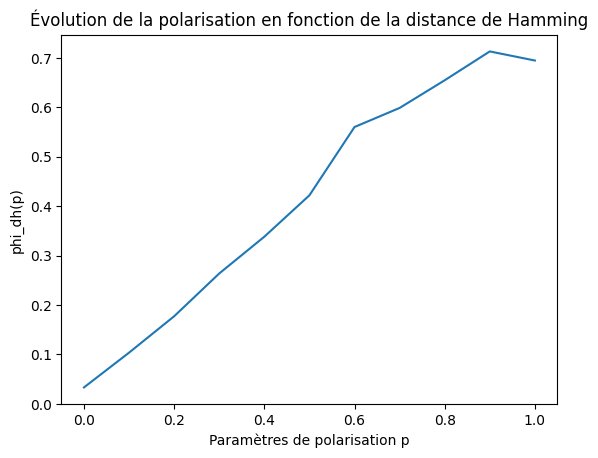

In [ ]:
import matplotlib.pyplot as plt
#nombre de répétitions pour chaque niveau de polarisation utilisé afin de faire une moyenne stable
nb_tests = 100
#les différentes valeurs de polarisation possible en décimale (O = pas polarisé, 1 = polarisé)
niveaux_polarisation = [k/10 for k in range (11)]

phi = [] #on cree une liste pour pouvoir enregistrer les différentes valeurs données
#pour chaque niveau de polarisation
for polarisation in niveaux_polarisation:
    moyenne = 0
    for n in range (nb_tests):
        #on génère un profil avec 20 votantes, 6 candidate et le niveau de polarisation donné dans la boucle
        p = generer_approbation_profil(20, 6, polarisation)
        #on calcul phi_hamming
        moyenne += phi_hamming(p)
        #on ajoute cette valeure par rapport au nombre de test que l'on a et on ajoute ce resultat dans notre liste phi
    phi.append(moyenne/nb_tests)
#on trace la graphique grâce à la bibliothèque matplotlib
plt.plot(niveaux_polarisation, phi)
plt.xlabel("Paramètres de polarisation p")
plt.ylabel("phi_dh(p)")
plt.title("Évolution de la polarisation en fonction de la distance de Hamming")
plt.show()

### Évolution des mesures 𝜑_ds

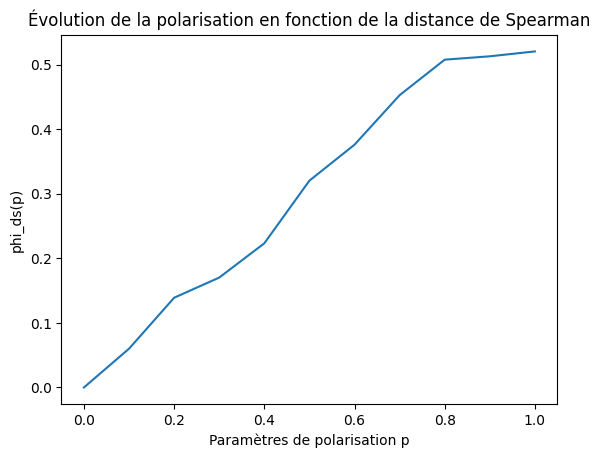

In [ ]:
#nombre de répétitions pour chaque niveau de polarisation utilisé afin de faire une moyenne stable
nb_tests = 100
#les différentes valeurs de polarisation possible en décimale (O = pas polarisé, 1 = polarisé)
niveaux_polarisation = [k/10 for k in range (11)]

phi = [] #on cree une liste pour pouvoir enregistrer les différentes valeurs données
#pour chaque niveau de polarisation
for polarisation in niveaux_polarisation:
    moyenne = 0
    for n in range(nb_tests):
        #on génère un profil avec 20 votantes, 6 candidate et le niveau de polarisation donné dans la boucle
        p = generer_ordre_profil(20, 6, polarisation)
        #on calcul phi_spearman
        moyenne += phi_spearman(p)
    #on ajoute cette valeure par rapport au nombre de test que l'on a et on ajoute ce resultat dans notre liste phi
    phi.append(moyenne/nb_tests)
#on trace la graphique grâce à la bibliothèque matplotlib
plt.plot(niveaux_polarisation, phi)
plt.xlabel("Paramètres de polarisation p")
plt.ylabel("phi_ds(p)")
plt.title("Évolution de la polarisation en fonction de la distance de Spearman")
plt.show()